#LOAD AND EDA

In [ ]:
import json, os

token = {"username":"akshitapery","key":"KGAT_134866bcf3e099f26d09a36e5e6b6c1e"}

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(token, f)

!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
# Imports and config

import os, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd

import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --unzip -p /content/chest_xray

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:46<00:00, 14.8MB/s]



In [ ]:
!ls /content/chest_xray

chest_xray


In [ ]:
# Dataset paths

BASE  = "/content/chest_xray/chest_xray"
TRAIN = os.path.join(BASE, "train")
VAL   = os.path.join(BASE, "val")
TEST  = os.path.join(BASE, "test")
classes = ["NORMAL", "PNEUMONIA"]
COLORS  = {"NORMAL": "#2ecc71", "PNEUMONIA": "#e74c3c"}

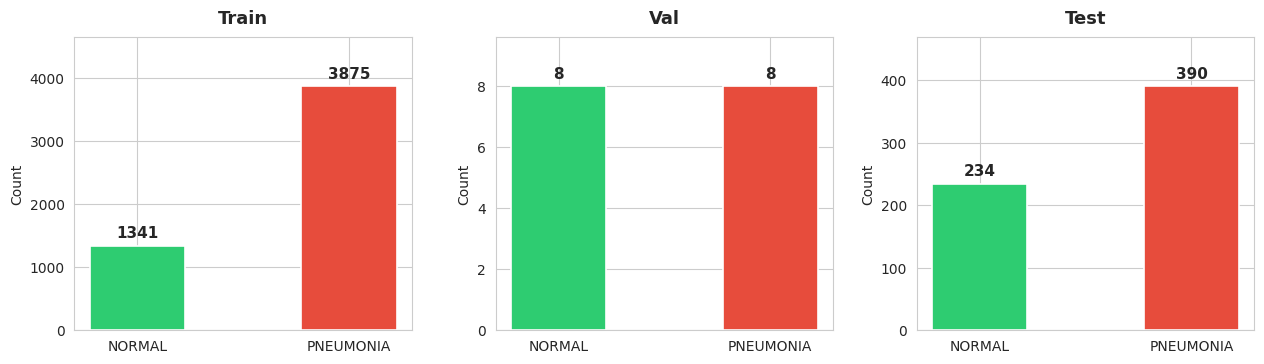

In [ ]:
# Class distribution across splits

splits = {"Train": TRAIN, "Val": VAL, "Test": TEST}
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (split, path) in zip(axes, splits.items()):
    counts = {cls: len(os.listdir(os.path.join(path, cls))) for cls in classes}
    bars = ax.bar(counts.keys(), counts.values(),
                  color=[COLORS[c] for c in counts.keys()], width=0.45, edgecolor="white", linewidth=1.2)
    ax.set_title(split, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_ylim(0, max(counts.values()) * 1.2)
    ax.tick_params(axis="x", labelsize=10)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts.values())*0.02,
                str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout(pad=2.0)
plt.show()

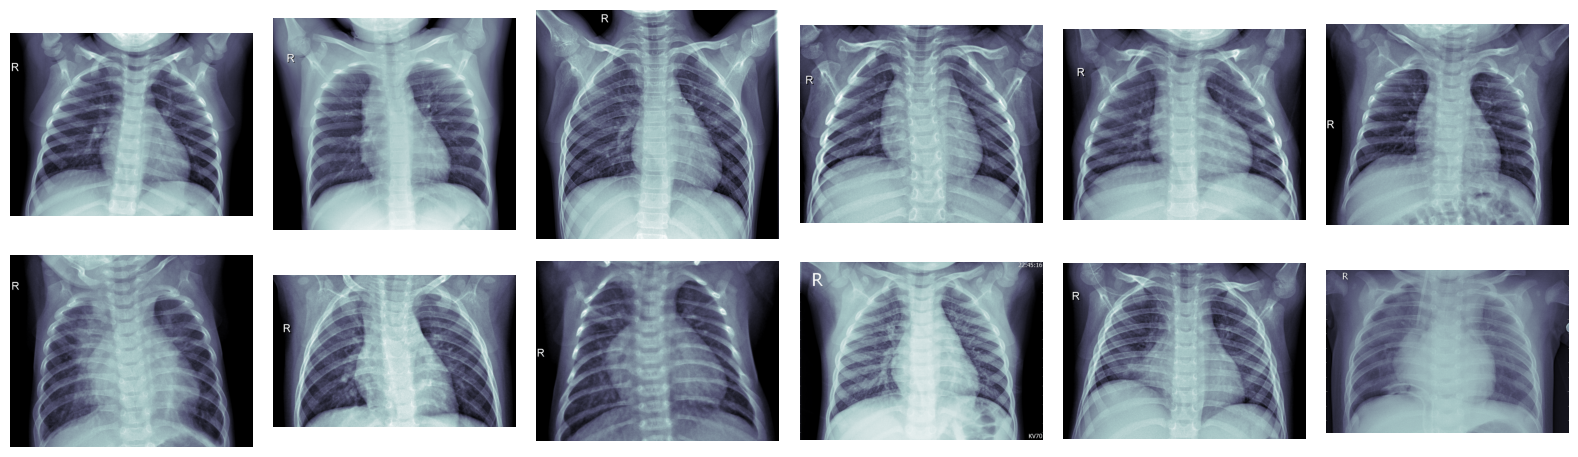

In [ ]:
# Sample X-rays per class

fig, axes = plt.subplots(2, 6, figsize=(16, 5))

for row, cls in enumerate(classes):
    folder = os.path.join(TRAIN, cls)
    fnames = os.listdir(folder)[:6]
    for col, fname in enumerate(fnames):
        img = Image.open(os.path.join(folder, fname)).convert("L")
        axes[row][col].imshow(img, cmap="bone")
        axes[row][col].axis("off")
    axes[row][0].set_ylabel(cls, fontsize=11, fontweight="bold",
                             color=COLORS[cls], rotation=90, labelpad=8)

plt.tight_layout(pad=1.5)
plt.show()

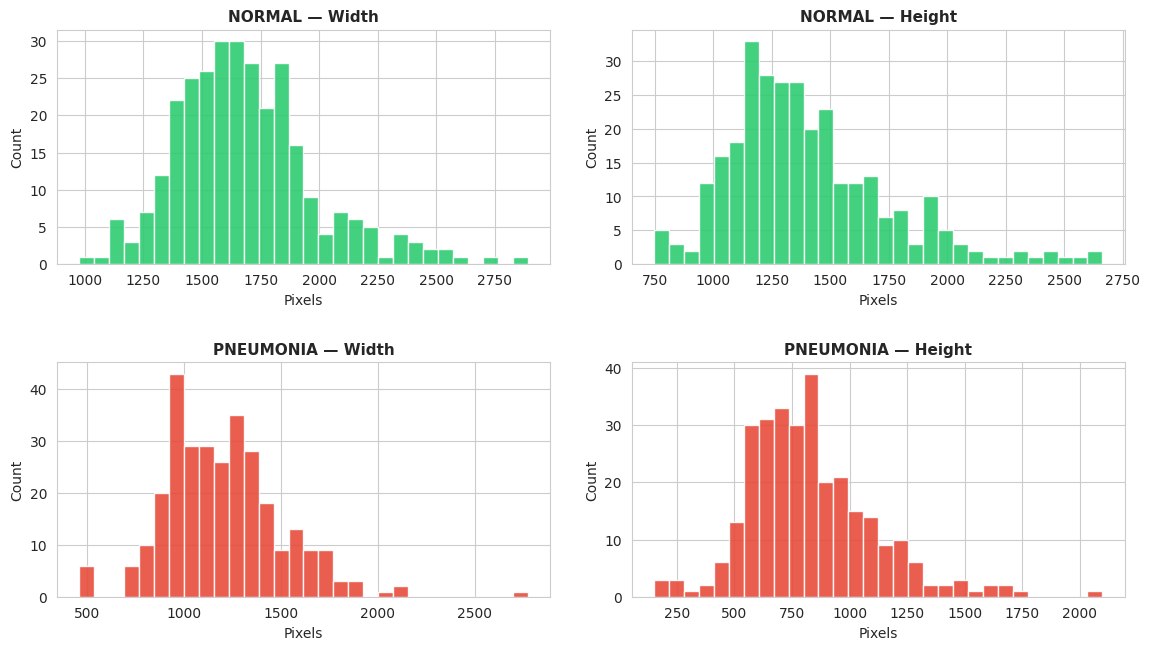

In [ ]:
# Image size (W x H) distribution per class

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for row, cls in enumerate(classes):
    folder = os.path.join(TRAIN, cls)
    widths, heights = [], []
    for fname in os.listdir(folder)[:300]:
        w, h = Image.open(os.path.join(folder, fname)).size
        widths.append(w); heights.append(h)

    c = COLORS[cls]
    axes[row][0].hist(widths, bins=30, color=c, edgecolor="white", alpha=0.9)
    axes[row][0].set_title(f"{cls} — Width", fontsize=11, fontweight="bold")
    axes[row][0].set_xlabel("Pixels"); axes[row][0].set_ylabel("Count")

    axes[row][1].hist(heights, bins=30, color=c, edgecolor="white", alpha=0.9)
    axes[row][1].set_title(f"{cls} — Height", fontsize=11, fontweight="bold")
    axes[row][1].set_xlabel("Pixels"); axes[row][1].set_ylabel("Count")

plt.tight_layout(pad=2.5)
plt.show()

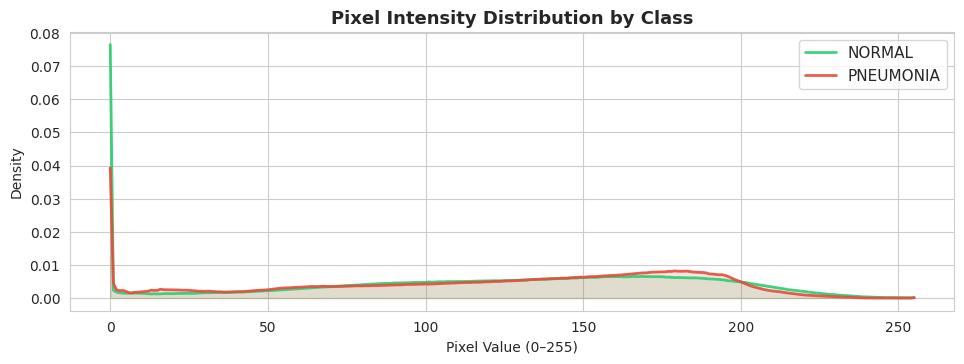

In [ ]:
# Pixel intensity distribution per class

fig, ax = plt.subplots(figsize=(10, 4))

for cls in classes:
    folder = os.path.join(TRAIN, cls)
    all_pixels = []
    for fname in os.listdir(folder)[:150]:
        arr = np.array(Image.open(os.path.join(folder, fname)).convert("L").resize((224, 224)))
        all_pixels.append(arr.flatten())
    hist, edges = np.histogram(np.concatenate(all_pixels), bins=256, range=(0,255), density=True)
    ax.plot(hist, color=COLORS[cls], label=cls, linewidth=2, alpha=0.9)
    ax.fill_between(range(256), hist, color=COLORS[cls], alpha=0.15)

ax.set_title("Pixel Intensity Distribution by Class", fontsize=13, fontweight="bold")
ax.set_xlabel("Pixel Value (0–255)"); ax.set_ylabel("Density"); ax.legend(fontsize=11)
plt.tight_layout(pad=2.0)
plt.show()

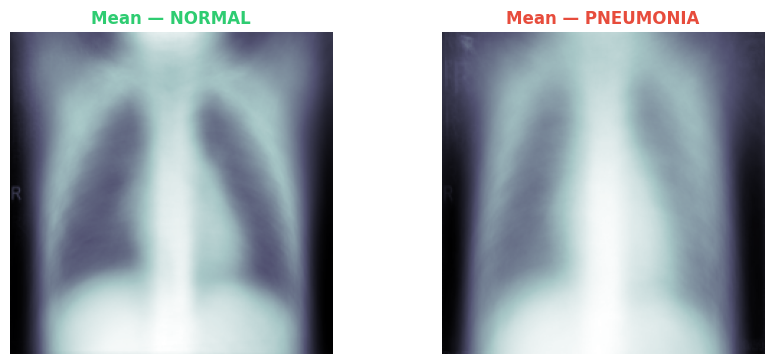

In [ ]:
# Mean X-ray per class

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, cls in zip(axes, classes):
    folder = os.path.join(TRAIN, cls)
    stack = [np.array(Image.open(os.path.join(folder, f)).convert("L").resize((224, 224)), dtype=np.float32)
             for f in os.listdir(folder)[:200]]
    ax.imshow(np.mean(stack, axis=0), cmap="bone")
    ax.set_title(f"Mean — {cls}", fontsize=12, fontweight="bold", color=COLORS[cls])
    ax.axis("off")

plt.tight_layout(pad=2.0)
plt.show()

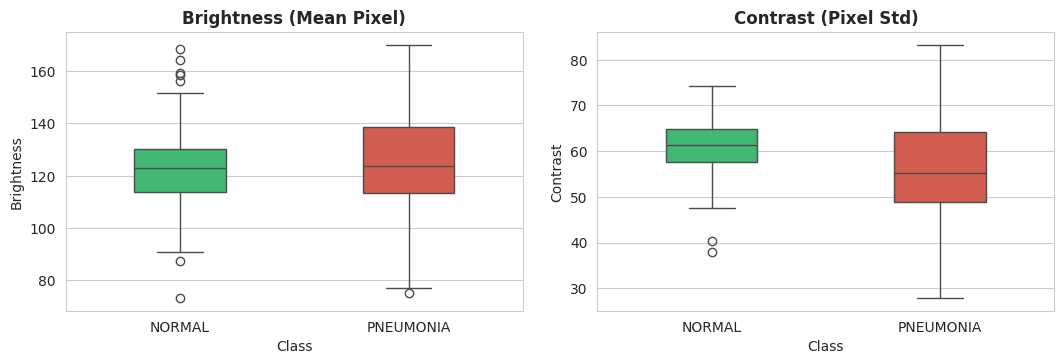

In [ ]:
# Brightness and contrast stats per class

records = []
for cls in classes:
    folder = os.path.join(TRAIN, cls)
    for fname in os.listdir(folder)[:200]:
        arr = np.array(Image.open(os.path.join(folder, fname)).convert("L").resize((224,224)), dtype=np.float32)
        records.append({"Class": cls, "Brightness": arr.mean(), "Contrast": arr.std()})

df = pd.DataFrame(records)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=df, x="Class", y="Brightness", palette=COLORS, ax=axes[0], width=0.4)
axes[0].set_title("Brightness (Mean Pixel)", fontsize=12, fontweight="bold")

sns.boxplot(data=df, x="Class", y="Contrast", palette=COLORS, ax=axes[1], width=0.4)
axes[1].set_title("Contrast (Pixel Std)", fontsize=12, fontweight="bold")

plt.tight_layout(pad=2.0)
plt.show()

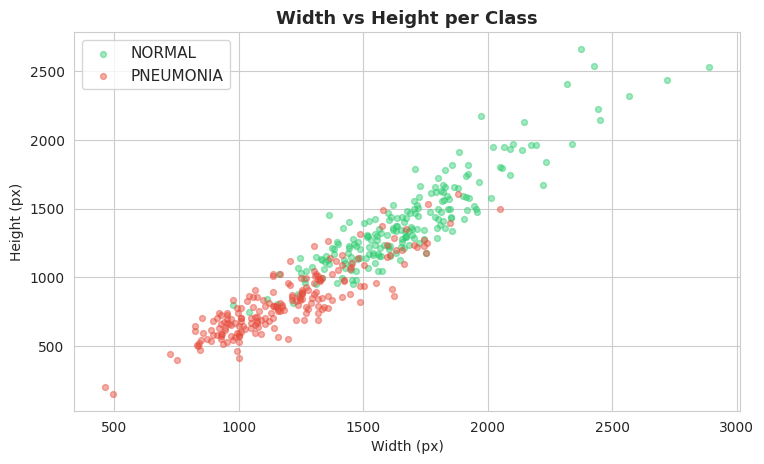

In [ ]:
# Aspect ratio scatter: width vs height per class

fig, ax = plt.subplots(figsize=(8, 5))

for cls in classes:
    folder = os.path.join(TRAIN, cls)
    ws, hs = [], []
    for fname in os.listdir(folder)[:200]:
        w, h = Image.open(os.path.join(folder, fname)).size
        ws.append(w); hs.append(h)
    ax.scatter(ws, hs, c=COLORS[cls], label=cls, alpha=0.45, s=18)

ax.set_title("Width vs Height per Class", fontsize=13, fontweight="bold")
ax.set_xlabel("Width (px)"); ax.set_ylabel("Height (px)"); ax.legend(fontsize=11)
plt.tight_layout(pad=2.0)
plt.show()

# MODEL

In [ ]:
# Three different augmentation strategies for model soup

transform_base = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_A = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_B = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_C = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomEqualize(p=0.5),
    transforms.RandomAdjustSharpness(2, p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# Build dataloaders for each augmentation policy

def get_loaders(train_tf, batch_size=32):
    train_ds = datasets.ImageFolder(TRAIN, transform=train_tf)
    test_ds  = datasets.ImageFolder(TEST,  transform=transform_base)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_dl, test_dl

loader_A, test_loader = get_loaders(transform_A)
loader_B, _           = get_loaders(transform_B)
loader_C, _           = get_loaders(transform_C)

print(f"Train batches: {len(loader_A)} | Test batches: {len(test_loader)}")
print(f"Classes: {loader_A.dataset.classes}")

Train batches: 163 | Test batches: 20
Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
# EfficientNet-B0 builder with custom head

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def build_model():
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(model.classifier[1].in_features, 2)
    )
    return model.to(device)

model_A = build_model()
model_B = build_model()
model_C = build_model()
print("Models built.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 204MB/s]


Models built.


In [ ]:
# Training loop

from torch.optim.lr_scheduler import CosineAnnealingLR

def train_model(model, loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    model.train()
    for epoch in range(epochs):
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct    += (out.argmax(1) == labels).sum().item()
            total      += labels.size(0)
        scheduler.step()
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.4f} | Acc: {100*correct/total:.2f}%")
    return model

In [ ]:
# Train each model on its augmentation policy

print("=== Training Model A (flip + rotate) ===")
model_A = train_model(model_A, loader_A)

print("\n=== Training Model B (affine + crop) ===")
model_B = train_model(model_B, loader_B)

print("\n=== Training Model C (equalize + sharpen) ===")
model_C = train_model(model_C, loader_C)

=== Training Model A (flip + rotate) ===
  Epoch 1/5 | Loss: 0.1387 | Acc: 94.86%
  Epoch 2/5 | Loss: 0.0751 | Acc: 97.18%
  Epoch 3/5 | Loss: 0.0471 | Acc: 98.04%
  Epoch 4/5 | Loss: 0.0321 | Acc: 98.75%
  Epoch 5/5 | Loss: 0.0190 | Acc: 99.35%

=== Training Model B (affine + crop) ===
  Epoch 1/5 | Loss: 0.1395 | Acc: 95.02%
  Epoch 2/5 | Loss: 0.0879 | Acc: 96.99%
  Epoch 3/5 | Loss: 0.0566 | Acc: 98.06%
  Epoch 4/5 | Loss: 0.0379 | Acc: 98.66%
  Epoch 5/5 | Loss: 0.0197 | Acc: 99.39%

=== Training Model C (equalize + sharpen) ===
  Epoch 1/5 | Loss: 0.1459 | Acc: 94.75%
  Epoch 2/5 | Loss: 0.0772 | Acc: 97.12%
  Epoch 3/5 | Loss: 0.0562 | Acc: 98.06%
  Epoch 4/5 | Loss: 0.0360 | Acc: 98.60%
  Epoch 5/5 | Loss: 0.0221 | Acc: 99.14%


In [ ]:
# Interpolate weights of all 3 models — the actual model soup

def model_soup(models):
    soup = build_model()
    soup_state = soup.state_dict()
    for key in soup_state:
        soup_state[key] = torch.stack([m.state_dict()[key].float() for m in models]).mean(0)
    soup.load_state_dict(soup_state)
    return soup

soup_model = model_soup([model_A, model_B, model_C])
print("Model soup ready.")

Model soup ready.


In [ ]:
# Evaluation helper

from sklearn.metrics import classification_report, confusion_matrix

def evaluate(model, loader, name="Model"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    acc = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\n{'='*40}")
    print(f"{name} — Accuracy: {acc:.2f}%")
    print(classification_report(all_labels, all_preds, target_names=classes))
    return acc, all_preds, all_labels

In [ ]:
# Evaluate and compare individual models vs soup

acc_A, _, _         = evaluate(model_A,    test_loader, "Model A")
acc_B, _, _         = evaluate(model_B,    test_loader, "Model B")
acc_C, _, _         = evaluate(model_C,    test_loader, "Model C")
acc_S, preds, lbls  = evaluate(soup_model, test_loader, "Model Soup")


Model A — Accuracy: 77.72%
              precision    recall  f1-score   support

      NORMAL       0.99      0.41      0.58       234
   PNEUMONIA       0.74      1.00      0.85       390

    accuracy                           0.78       624
   macro avg       0.86      0.70      0.71       624
weighted avg       0.83      0.78      0.75       624


Model B — Accuracy: 93.59%
              precision    recall  f1-score   support

      NORMAL       0.96      0.87      0.91       234
   PNEUMONIA       0.92      0.98      0.95       390

    accuracy                           0.94       624
   macro avg       0.94      0.92      0.93       624
weighted avg       0.94      0.94      0.94       624


Model C — Accuracy: 80.77%
              precision    recall  f1-score   support

      NORMAL       0.99      0.49      0.66       234
   PNEUMONIA       0.77      1.00      0.87       390

    accuracy                           0.81       624
   macro avg       0.88      0.74      0.76 

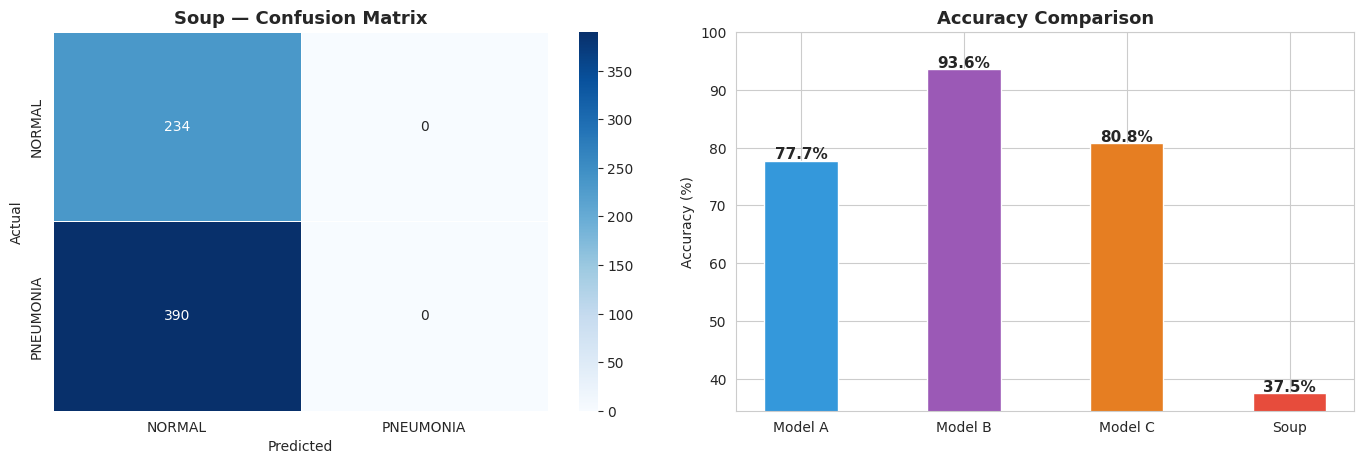

In [ ]:
# Final comparison plot — confusion matrix + accuracy bar

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(lbls, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes,
            yticklabels=classes, ax=axes[0], linewidths=0.5)
axes[0].set_title("Soup — Confusion Matrix", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

names  = ["Model A", "Model B", "Model C", "Soup"]
accs   = [acc_A, acc_B, acc_C, acc_S]
colors = ["#3498db", "#9b59b6", "#e67e22", "#e74c3c"]
bars   = axes[1].bar(names, accs, color=colors, width=0.45, edgecolor="white")
axes[1].set_ylim(min(accs) - 3, 100)
axes[1].set_title("Accuracy Comparison", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Accuracy (%)")
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{acc:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout(pad=2.0)
plt.show()